In [1]:
1+1


2

In [18]:
from typing import Annotated
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START,END
from langgraph.graph.message import add_messages

In [19]:
class State(TypedDict):
    #messages have type list 
    #the add_messages function in the annotation defines how state key should be updated
    # in this case it will apppend the new messages to the existing list of messages
    messages: Annotated[list, add_messages]

graph_builder = StateGraph(State)

In [ ]:
graph_builder

In [20]:
import os 
from dotenv import load_dotenv
load_dotenv()

True

In [3]:
from langchain_groq import ChatGroq

llm = ChatGroq(
    model="llama-3.1-8b-instant",
    api_key=os.environ.get("GROQ_API_KEY"))

In [ ]:
from langchain_google_genai  import ChatGoogleGenerativeAI
import os 
os.environ["GOOGLE_API_KEY"]=os.getenv("GOOGLE_API_KEY")

llm_gem=ChatGoogleGenerativeAI(model="gemini-2.5-flash")

In [ ]:
llm


In [ ]:
#node Functionality 
def chatbot(state:State):
    return {"messages":[llm.invoke(state["messages"])]}


In [ ]:
graph_builder=StateGraph(State)
#adding node
graph_builder.add_node("llm chatbot",chatbot)

#addding edges
graph_builder.add_edge(START,"llm chatbot")
graph_builder.add_edge("llm chatbot",END)

#compile the graph
graph=graph_builder.compile()


In [ ]:
#visulization of the graph
from IPython.display import display,Image
try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception as e:
    
    pass

In [ ]:
response=graph.invoke({"messages":["Hello!"]})
response["messages"][-1].content

In [ ]:
for event in graph.stream({"messages":["Hello!","what is langchain?","What is metadata?","what is langchain?","can you show me my previous inputs?"]}):
    for val in event.values():
        print(val["messages"][-1].content)

ChatBot with Tools

In [9]:
from langchain_tavily import TavilySearch

tool = TavilySearch(max_results=3, api_key=os.environ.get("TAVILY_API_KEY"))


In [10]:
##Custom Function
def multiply(a:int,b:int)->int:
    """ only use for multiplication of two numbers
    Multiply a and b
    ARGS:
    a(int): first number
    b(int): second number
    RETURNS:
    int: product of a and b
    """


    return a*b

In [11]:
tools=[tool,multiply]


In [55]:
llm_with_tools=llm.bind_tools(tools)
llm_with_tools

_ChatModelBinding(bound=ChatGroq(metadata={'lc_versions': {'langchain-core': '1.5.0', 'langchain': '1.3.14'}}, output_version=None, profile={'name': 'Llama 3.1 8B Instant', 'release_date': '2024-07-23', 'last_updated': '2024-07-23', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 131072, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x00000244B9EFA900>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x00000244B9EFB380>, model_name='llama-3.1-8b-instant', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None), kwargs={'tools': [{'type': 'function', 'function': {'name': 'tavily_search', 'description': 'A search engin

In [6]:
from langgraph.graph  import StateGraph, START, END
from langgraph.prebuilt import ToolNode , tools_condition
from langgraph.checkpoint.memory import MemorySaver


In [14]:
def tool_calling_llm(state:State):
    return {"messages":[llm_with_tools.invoke(state["messages"])]}

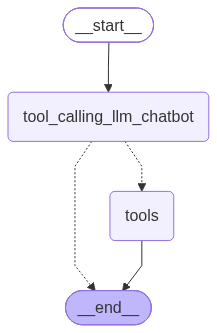

In [67]:
##Graph
builder=StateGraph(State)
builder.add_node("tool_calling_llm_chatbot",tool_calling_llm)
builder.add_node("tools",ToolNode(tools))


#adding egdes

builder.add_edge(START,"tool_calling_llm_chatbot")

builder.add_conditional_edges("tool_calling_llm_chatbot",tools_condition)
builder.add_edge("tools",END)


#compile the graph
graph=builder.compile()
graph


In [59]:
response=graph.invoke({"messages":"What is recent ai news?"})
response["messages"][-1].content

'{"query": "recent AI news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.foxbusiness.com/technology/openai-co-founder-warns-ai-models-becoming-harder-control-after-its-model-hacked-another-firm", "title": "OpenAI co-founder warns AI models are becoming harder to control after its model hacked another firm - Fox Business", "score": 0.69672287, "published_date": "Fri, 24 Jul 2026 14:17:22 GMT", "content": "* #### It’s important to look for tech’s ‘beneficiaries,’ expert says. * #### Google is \'out of the top 10\' in AI, expert says. OpenAI co-founder and president Greg Brockman said at an event that AI models are becoming so advanced and multi-faceted that engineers are struggling to monitor and control them. Brockman, while speaking at a private OpenAI media roundtable in New York City this week, addressed a recent incident where one of the company\'s AI models broke out of what was supposed to be a secure sandbox and hacked into Hugging 

In [60]:
for m in response["messages"]:
    print(m.pretty_print())

================================ Human Message =================================

What is recent ai news?
None
================================== Ai Message ==================================
Tool Calls:
  tavily_search (wj0f3s85g)
 Call ID: wj0f3s85g
  Args:
    query: recent AI news
    topic: news
None
================================= Tool Message =================================
Name: tavily_search

{"query": "recent AI news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.foxbusiness.com/technology/openai-co-founder-warns-ai-models-becoming-harder-control-after-its-model-hacked-another-firm", "title": "OpenAI co-founder warns AI models are becoming harder to control after its model hacked another firm - Fox Business", "score": 0.69672287, "published_date": "Fri, 24 Jul 2026 14:17:22 GMT", "content": "* #### It’s important to look for tech’s ‘beneficiaries,’ expert says. * #### Google is 'out of the top 10' in AI, expert says. OpenAI c

In [61]:
response_multy=graph.invoke({"messages":"what is the multiplication of 52 and 100?"})


In [62]:
for m in response_multy["messages"]:
    print(m.pretty_print())

================================ Human Message =================================

what is the multiplication of 52 and 100?
None
================================== Ai Message ==================================
Tool Calls:
  multiply (na0cxmam6)
 Call ID: na0cxmam6
  Args:
    a: 52
    b: 100
None
================================= Tool Message =================================
Name: multiply

5200
None


In [63]:
response_add=graph.invoke({"messages":"what is the addition of 52 and 100?"})

In [64]:
for m in response_add["messages"]:
    print(m.pretty_print())

================================ Human Message =================================

what is the addition of 52 and 100?
None
================================== Ai Message ==================================
Tool Calls:
  multiply (pn65ew4ny)
 Call ID: pn65ew4ny
  Args:
    a: 52
    b: 100
None
================================= Tool Message =================================
Name: multiply

5200
None


ReAct Agent Architecture

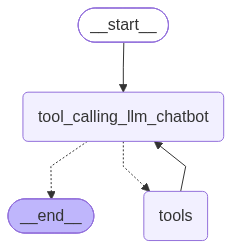

In [73]:
##Graph
builder=StateGraph(State)
builder.add_node("tool_calling_llm_chatbot",tool_calling_llm)
builder.add_node("tools",ToolNode(tools))


#adding egdes

builder.add_edge(START,"tool_calling_llm_chatbot")
builder.add_conditional_edges("tool_calling_llm_chatbot",tools_condition)
builder.add_edge("tools","tool_calling_llm_chatbot")


#compile the graph
graph_react=builder.compile()
graph_react 


In [71]:
res=graph_react.invoke({"messages":"tell me the recent ai news and also multiply 52 and 100 and also add 52 and 100"})

In [72]:
for m in res["messages"]:
    print(m.pretty_print())

================================ Human Message =================================

tell me the recent ai news and also multiply 52 and 100 and also add 52 and 100
None
================================== Ai Message ==================================
Tool Calls:
  tavily_search (9ne1wtafh)
 Call ID: 9ne1wtafh
  Args:
    query: recent AI news
    time_range: day
    topic: news
  multiply (k9jh2xayn)
 Call ID: k9jh2xayn
  Args:
    a: 52
    b: 100
  multiply (gjsawvt7z)
 Call ID: gjsawvt7z
  Args:
    a: 52
    b: 100
None
================================= Tool Message =================================
Name: tavily_search

{"query": "recent AI news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.foxnews.com/tech/ai-newsletter-white-house-monitoring-openai-containment-escape-hugging-face-hack", "title": "Fox News AI Newsletter: White House monitoring OpenAI containment escape, Hugging Face hack - Fox News", "score": 0.64128816, "published_date

Adding memory in Agentic Graph

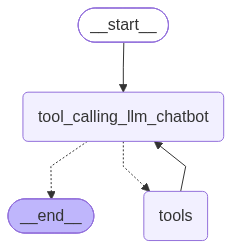

In [21]:
 ##Graph
builder=StateGraph(State)
builder.add_node("tool_calling_llm_chatbot",tool_calling_llm)
builder.add_node("tools",ToolNode(tools))
memory =MemorySaver()
#adding egdes

builder.add_edge(START,"tool_calling_llm_chatbot")
builder.add_conditional_edges("tool_calling_llm_chatbot",tools_condition)
builder.add_edge("tools","tool_calling_llm_chatbot")


#compile the graph
graph_memory=builder.compile(checkpointer=memory)
graph_memory

In [22]:
llm_with_tools=llm_gem.bind_tools(tools)


llm_with_tools

_ChatModelBinding(bound=ChatGoogleGenerativeAI(metadata={'lc_versions': {'langchain-core': '1.5.1', 'langchain': '1.3.14', 'langchain-google-genai': '4.3.2'}}, output_version=None, profile={}, google_api_key=SecretStr('**********'), location=None, model='chat-bison-001', client=<google.genai.client.Client object at 0x00000193B925C050>, default_metadata=(), model_kwargs={}), kwargs={'tools': [{'type': 'function', 'function': {'name': 'tavily_search', 'description': 'A search engine optimized for comprehensive, accurate, and trusted results. Useful for when you need to answer questions about current events. It not only retrieves URLs and snippets, but offers advanced search depths, domain management, time range filters, and image search, this tool delivers real-time, accurate, and citation-backed results.Input should be a search query.', 'parameters': {'properties': {'query': {'description': 'Search query to look up', 'type': 'string'}, 'include_domains': {'anyOf': [{'items': {'type': 's

In [23]:
config={"configurable":{"thread_id":1}}

In [24]:
response_1=graph_memory.invoke({"messages":" i like msd in cricket"},config=config)

ChatGoogleGenerativeAIError: Error calling model 'chat-bison-001' (NOT_FOUND): 404 NOT_FOUND. {'error': {'code': 404, 'message': 'models/chat-bison-001 is not found for API version v1beta, or is not supported for generateContent. Call ModelService.ListModels to see the list of available models and their supported methods.', 'status': 'NOT_FOUND'}}

In [85]:
response_1["messages"][-1].content

'MSD in cricket refers to MS Dhoni, a former Indian cricketer who played as a wicket-keeper batsman. He is widely regarded as one of the greatest cricketers of all time, known for his aggressive batting style and exceptional leadership skills. Dhoni has played for the Indian national team and has also been the captain of the team, leading them to several victories in international competitions. He is also the former captain of the Chennai Super Kings (CSK) team in the Indian Premier League (IPL).'

In [86]:
response_2=graph_memory.invoke({"messages":" who do i like in cricket"},config=config)

In [87]:
for m in response_2["messages"]:
    print(m.pretty_print())

================================ Human Message =================================

 i like msd 
None
================================== Ai Message ==================================
Tool Calls:
  tavily_search (jhqmv7pmt)
 Call ID: jhqmv7pmt
  Args:
    query: MSD
    topic: general
None
================================= Tool Message =================================
Name: tavily_search

{"query": "MSD", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://en.wikipedia.org/wiki/MSD", "title": "MSD - Wikipedia", "content": "[edit]\n\n Merck Sharp and Dohme (MSD) \"MSD (company)\"), an international name of Merck & Co., the U.S. and Canada pharmaceutical company formerly related to German Merck KGaA\n MSD Capital, a private investment firm owned by personal computer entrepreneur Michael Dell\n MSD Ignition, a company that specializes in automotive-ignition components; MSD stands for \"multiple spark discharge\"\n Motor Sports Developments, an automotive-